In [6]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

from tqdm import tqdm
import math


# np.set_printoptions(precision=4)

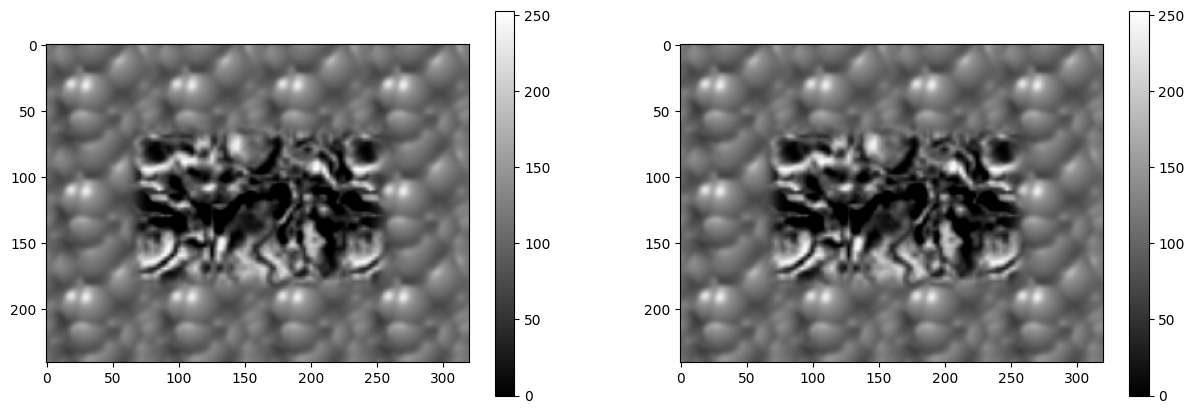

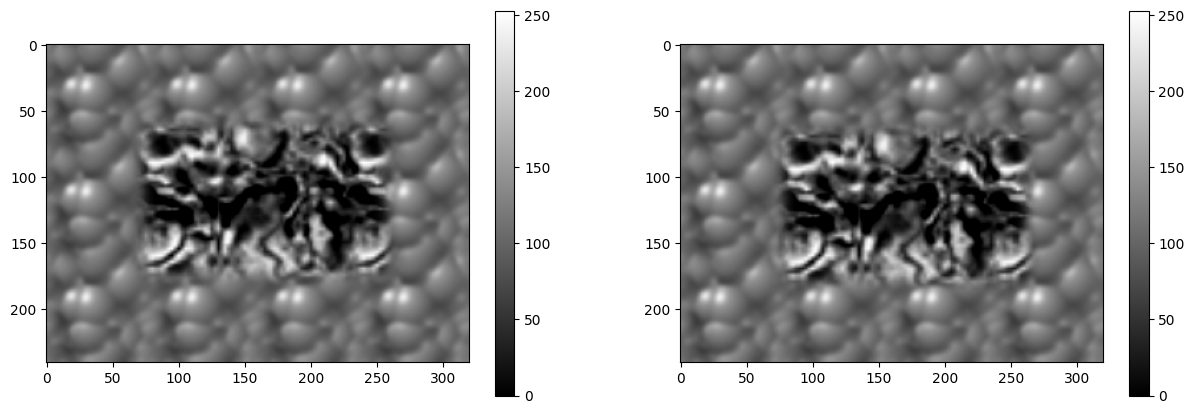

In [7]:
input_dir = Path('TestSeq')

shift_0 = cv.imread(str(input_dir / 'Shift0.png'), cv.IMREAD_GRAYSCALE)
shift_r2 = cv.imread(str(input_dir / 'ShiftR2.png'), cv.IMREAD_GRAYSCALE)
shift_r5u5 = cv.imread(str(input_dir / 'ShiftR5U5.png'), cv.IMREAD_GRAYSCALE)
shift_r10 = cv.imread(str(input_dir / 'ShiftR10.png'), cv.IMREAD_GRAYSCALE)
shift_r20 = cv.imread(str(input_dir / 'ShiftR20.png'), cv.IMREAD_GRAYSCALE)
shift_r40 = cv.imread(str(input_dir / 'ShiftR40.png'), cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(shift_0, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(shift_r2, cmap="gray")
plt.colorbar()
plt.show()


plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(shift_r5u5, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(shift_r10, cmap="gray")
plt.colorbar()
plt.show()

In [8]:
def gradients(img, kernel_size=3, sigma=3):
    # img = img.copy().astype(np.float32)
    img = cv.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=kernel_size)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=kernel_size)

    # sobelx = np.uint8(np.absolute(sobelx))    
    # sobely = np.uint8(np.absolute(sobely))    
    return sobelx, sobely

def time_gradient(imgt1, imgt2):
    # return imgt1 - imgt2
    return imgt2 - imgt1


def displacement_vector(Ix, Iy, It, window_size=3):
    sum_window = lambda I: cv.filter2D(I, ddepth=-1, kernel=np.ones((window_size, window_size), np.float32))
    # sum_window = lambda I: cv.GaussianBlur(I, (window_size, window_size), 5, normalized=False)

    summed_Ix2 = sum_window(Ix * Ix)
    summed_Iy2 = sum_window(Iy * Iy)
    summed_IxIy = sum_window(Ix * Iy)
    summed_IxIt = sum_window(Ix * It)
    summed_IyIt = sum_window(Iy * It)


    ATA = lambda i,j: np.array([[summed_Ix2[i,j], summed_IxIy[i,j]], 
                                  [summed_IxIy[i,j], summed_Iy2[i,j]]])
    ATb = lambda i,j: -1 * np.array([summed_IxIt[i,j], summed_IyIt[i,j]])

    u = np.zeros_like(Ix, dtype=np.float32)
    v = np.zeros_like(Ix, dtype=np.float32)

    # Populate the image using the function
    for i in range(u.shape[0]):
        for j in range(u.shape[1]):
            u[i,j], v[i,j] = solve(ATA(i,j), ATb(i,j))

    return u,v

def solve(A, b):
    return np.linalg.lstsq(A,b)[0]

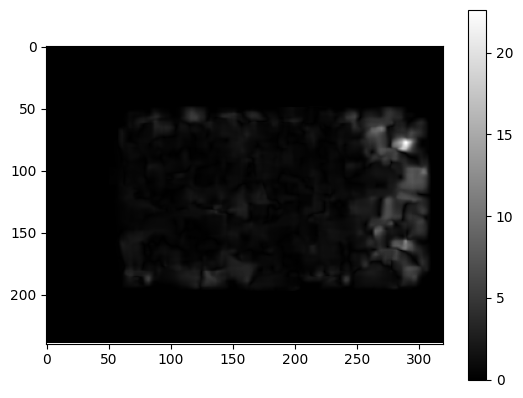

In [9]:
img = shift_0
imgt2 = shift_r40
k_size = 15
[Ix, Iy], It = gradients(img), time_gradient(img, imgt2)

u,v = displacement_vector(Ix,Iy,It,k_size)
plt.imshow(np.sqrt(np.square(u) + np.square(v)), cmap="gray")
plt.colorbar()
plt.show()

## Part 2
In lectures we described the Gaussian pyramid constructed using the REDUCE operator. Here is the original paper that defines the REDUCE and EXPAND operators:


### A

Write a function to implement REDUCE. Use this to produce a Gaussian Pyramid of 4 levels (0-3). Demonstrate using the first frame of the DataSeq1 sequence.

In [10]:
input_dir = Path('DataSeq1')

yos_1_warped = cv.imread(str(input_dir / 'yos_img_1_warped.jpg'), cv.IMREAD_GRAYSCALE)
yos_2_warped = cv.imread(str(input_dir / 'yos_img_2_warped.jpg'), cv.IMREAD_GRAYSCALE)
yos_1 = cv.imread(str(input_dir / 'yos_img_01.jpg'), cv.IMREAD_GRAYSCALE)
yos_2 = cv.imread(str(input_dir / 'yos_img_02.jpg'), cv.IMREAD_GRAYSCALE)
yos_3 = cv.imread(str(input_dir / 'yos_img_03.jpg'), cv.IMREAD_GRAYSCALE)

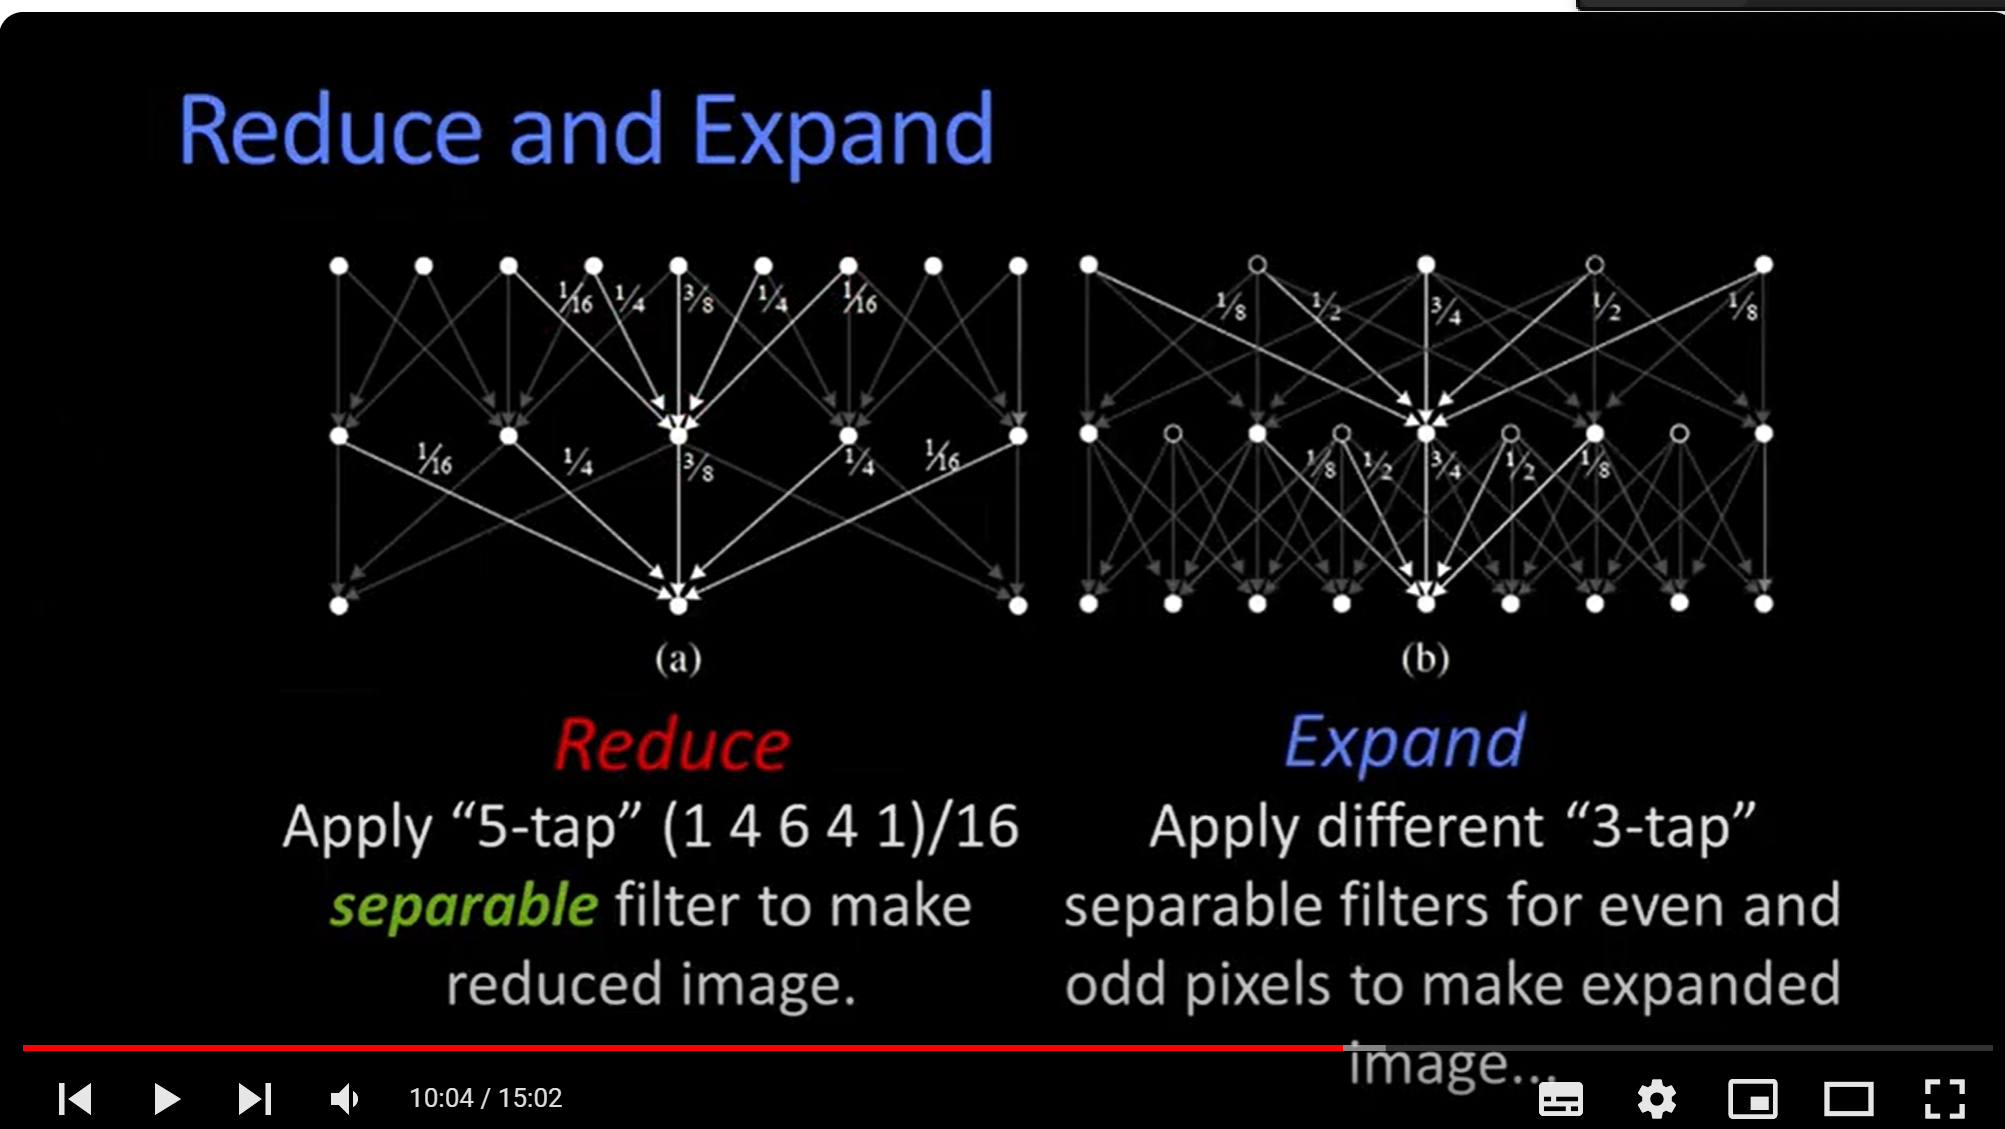

In [59]:
def REUDCE(img):
    kernel = np.array([1,4,6,4,1],dtype=np.float32)
    kernel = kernel / sum(kernel)

    # filtered_image = cv.sepFilter2D(img, ddepth=cv.CV_32F, kernelX=kernel, kernelY=np.array([1/2,1/2], dtype=np.float32))
    filtered_image = cv.sepFilter2D(img, ddepth=cv.CV_32F, kernelX=kernel, kernelY=kernel)
    return filtered_image[::2,::2]

def convolve_1d(a, v, vertically=True):
    if vertically:
        return np.array([np.convolve(a[i],v, "same") for i in range(a.shape[0])])
    else:
        a = a.T
        convolved = np.array([np.convolve(a[i],v, "same") for i in range(a.shape[0])])
        return convolved.T

def EXPAND(img, new_shape):

    image_up = np.zeros((2*img.shape[0], 2*img.shape[1]))
    image_up[::2, ::2] = img
    new_image = np.zeros_like(image_up)

    kernel_odd = np.array([1,4,6,4,1],dtype=np.float32)
    kernel_odd = kernel_odd / sum(kernel_odd)

    kernel_even = np.array([1,0,1],dtype=np.float32)
    kernel_even = kernel_even / sum(kernel_even)

    kernel_none = np.array([1])

    # odd_filtered_image_cols = cv.sepFilter2D(image_up, ddepth=cv.CV_32F, kernelX=kernel_odd, kernelY=kernel_none)
    # odd_filtered_image_rows = cv.sepFilter2D(image_up, ddepth=cv.CV_32F, kernelX=kernel_none, kernelY=kernel_odd)
    # even_filtered_image_rows = cv.sepFilter2D(image_up, ddepth=cv.CV_32F, kernelX=kernel_none, kernelY=kernel_even)
    # even_filtered_image_cols = cv.sepFilter2D(image_up, ddepth=cv.CV_32F, kernelX=kernel_even, kernelY=kernel_none)

    odd_filtered_image_cols = convolve_1d(image_up, kernel_odd)
    odd_filtered_image_rows = convolve_1d(image_up, kernel_odd, False)
    even_filtered_image_rows = convolve_1d(image_up, kernel_even, False)
    even_filtered_image_cols = convolve_1d(image_up, kernel_even)

    new_image[0::2,0::2] = odd_filtered_image_rows[0::2,0::2] 
    new_image[0::2,1::2] = even_filtered_image_rows[0::2,1::2]
    new_image[1::2,0::2] = odd_filtered_image_cols[0::2, 0::2]
    new_image[1::2,1::2] = even_filtered_image_cols[1::2, 0::2]

    # image_up[1::2,]
    # even_columns = np.array([even_filtered_image[:,i][:,None] for i in range(even_filtered_image.shape[1])])
    # odd_columns = np.array([odd_filtered_image[:,i][:,None] for i in range(odd_filtered_image.shape[1])])
    # even_odd_arr = np.concatenate([[even_columns[i], odd_columns[i]] for i in range(even_filtered_image.shape[1])])
    # combined_columns = np.hstack(even_odd_arr)

    if new_shape[1] < new_image.shape[1]:
        new_image=new_image[:,:-1]

    if new_shape[0] < new_image.shape[0]:
        new_image=new_image[:-1,:]

    return new_image

# Returns gaussians reduced
def gaussian_pyramid(img, levels=4):
    gaussians = [img]
    for _ in range(levels):
        gaussians.append(REUDCE(gaussians[-1]))

    return gaussians      

def difference_of_gaussians(gaussians):
    # laplacians = [gaussians[i] - EXPAND(gaussians[i+1]) for i in range(len(gaussians)-1)]
    laplacians = [gaussians[i] - EXPAND(gaussians[i+1], gaussians[i].shape) for i in range(len(gaussians)-1)]
    return laplacians

# Returns all laplacians and the most coarse gaussian
def laplacian_pyramid(img, levels=4):
    gaussians = gaussian_pyramid(img, levels-1)
    print([g.shape for g in gaussians] )
    laplacians = difference_of_gaussians(gaussians)
    return laplacians, gaussians[-1]

# laplacians, coarse_gaussian = laplacian_pyramid(yos_1, levels=4)
# laplacians, coarse_gaussian = laplacian_pyramid(yos_1, levels=4)


[(252, 316), (126, 158), (63, 79), (32, 40)]
got 3 laplacians


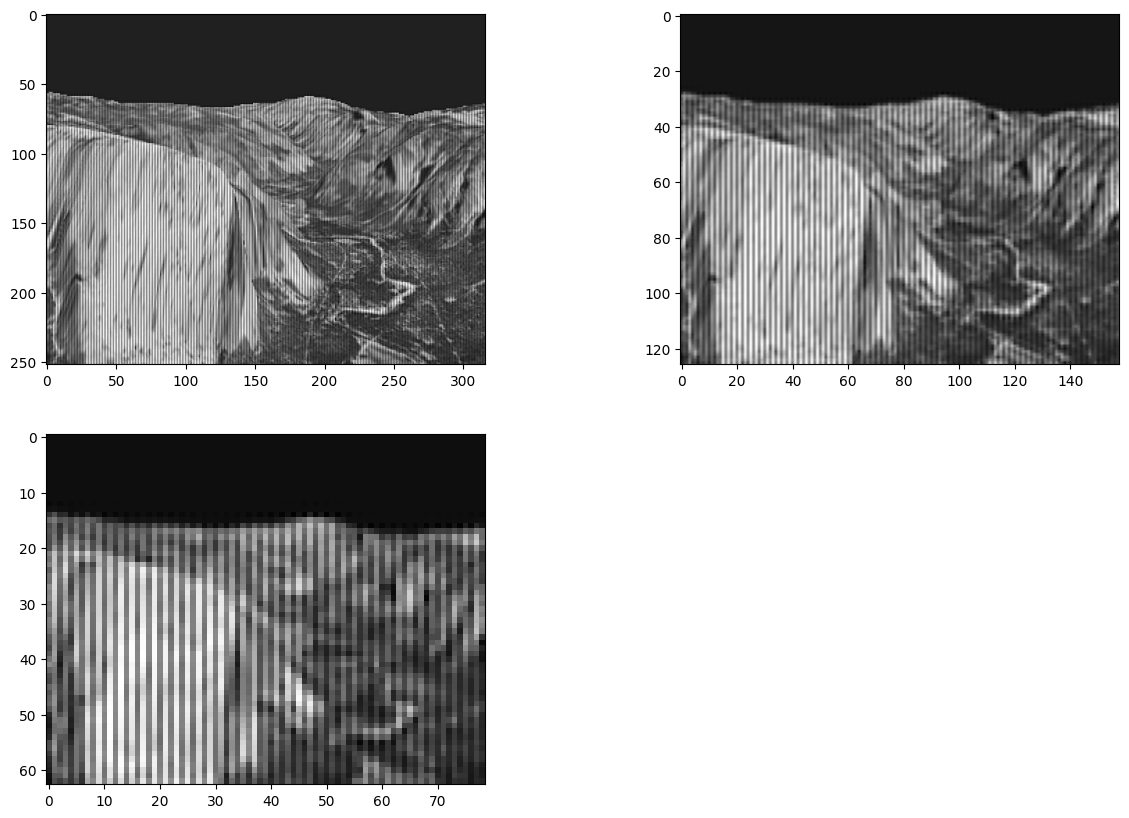

[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [14.28596473 78.73204041 71.43421268 ...  9.31169307 22.40190125
   9.39408708]
 [ 2.71388483 60.10015869 59.54867983 ...  6.97605455 19.32731628
  11.20805061]
 [-1.48966265 52.08952332 37.93919992 ...  7.98764884 22.02598572
  18.81340206]]


In [61]:
laplacians, coarse_gaussian = laplacian_pyramid(yos_1, levels=4)
print(f"got {len(laplacians)} laplacians")
plt.figure(figsize=(15,10))
plt.subplot(221)
plt.imshow(laplacians[0], cmap="gray")
plt.subplot(222)
plt.imshow(laplacians[1], cmap="gray")
plt.subplot(223)
plt.imshow(laplacians[2], cmap="gray")

plt.show()

In [2]:
def euclidean_to_homogenous(euclidean_pts):
    return np.hstack((euclidean_pts, np.ones((len(euclidean_pts), 1))))

def homogenous_to_euclidean(homogenous_pts):
    return np.array([pt[:-1] / pt[-1] for pt in homogenous_pts])

def get_point_value(original_img, warped_x, warped_y):
    f = lambda x,y: original_img[y,x] if 0<=x<original_img.shape[1] and 0<=y<original_img.shape[0] else 0
    i = math.floor(warped_x) # represents x-like coordinate
    j = math.floor(warped_y) # represents y-like coordinate

    a = warped_x - i
    b = warped_y - j
    
    value = (1-a)*(1-b)*f(i,j) + a*(1-b)*f(i+1,j) + a*b*f(i+1,j+1) +(1-a)*b*f(i,j+1)
    return value


def warp(img1, matrix_img1_to_img2):
    matrix_img2_to_img1 = np.linalg.inv(matrix_img1_to_img2)

    points_img2 = np.array([[x,y] for x in range(img1.shape[1]) for y in range(img1.shape[0])]) 
    homogenous_inverse_warped = [matrix_img2_to_img1 @ point for point in euclidean_to_homogenous(points_img2)]
    inverse_warped_indices = homogenous_to_euclidean(homogenous_inverse_warped)
    inverse_warped_indices = inverse_warped_indices.reshape((img1.shape[1],img1.shape[0],2))

    new_img = np.zeros_like(img1)

    for y in range(new_img.shape[0]):
        for x in range(new_img.shape[1]):
            new_img[y,x] = get_point_value(img1, *inverse_warped_indices[x,y])

    return new_img